# Flight Fuel Analysis: ML-Powered Aviation Sustainability

**Objective:** Predict fuel flow and CO2 emissions for global flights using real-time data from OpenSky Network and Open-Meteo APIs.

This notebook covers:
1. Data Collection (live flights + weather)
2. Feature Engineering (aerodynamic physics)
3. Exploratory Data Analysis
4. ML Model Training (Random Forest + XGBoost)
5. Model Evaluation & Explainability (SHAP)
6. Save Model Artifacts

In [1]:
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import joblib

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful.')

All imports successful.


---
## 1. Data Collection

We collect live flight data from the OpenSky Network API and weather data from the Open-Meteo API.

In [2]:
def fetch_opensky_flights(max_retries=3):
    url = 'https://opensky-network.org/api/states/all'
    for attempt in range(max_retries):
        try:
            print(f'Fetching flights from OpenSky (attempt {attempt + 1})...')
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            data = resp.json()
            
            if data.get('states') is None:
                print('No states returned. Retrying...')
                time.sleep(5)
                continue
            
            columns = [
                'icao24', 'callsign', 'origin_country', 'time_position',
                'last_contact', 'longitude', 'latitude', 'baro_altitude',
                'on_ground', 'velocity', 'true_track', 'vertical_rate',
                'sensors', 'geo_altitude', 'squawk', 'spi', 'position_source'
            ]
            
            df = pd.DataFrame(data['states'], columns=columns)
            print(f'Received {len(df)} total flight states.')
            return df
        except Exception as e:
            print(f'Error: {e}')
            if attempt < max_retries - 1:
                wait = 10 * (attempt + 1)
                print(f'Retrying in {wait}s...')
                time.sleep(wait)
    print('Failed to fetch from OpenSky.')
    return pd.DataFrame()

raw_flights = fetch_opensky_flights()
print(f'Raw shape: {raw_flights.shape}')

Fetching flights from OpenSky (attempt 1)...
Received 12036 total flight states.
Raw shape: (12036, 17)


In [3]:
def filter_cruise_flights(df, n_sample=1000):
    df = df.copy()
    required = ['latitude', 'longitude', 'baro_altitude', 'velocity', 'true_track']
    df = df.dropna(subset=required)
    for col in ['latitude', 'longitude', 'baro_altitude', 'velocity', 'true_track', 'vertical_rate']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=required)
    
    df = df[
        (df['on_ground'] == False) &
        (df['baro_altitude'] > 5000) &
        (df['velocity'] > 100) &
        (df['latitude'].between(-85, 85)) &
        (df['longitude'].between(-180, 180))
    ]
    df['callsign'] = df['callsign'].str.strip()
    print(f'Flights in cruise phase: {len(df)}')
    if len(df) > n_sample:
        df = df.sample(n=n_sample, random_state=42)
        print(f'Sampled down to {n_sample} flights.')
    return df.reset_index(drop=True)

flights = filter_cruise_flights(raw_flights, n_sample=1000)

Flights in cruise phase: 6106
Sampled down to 1000 flights.


In [4]:
def fetch_weather_for_flights(df, batch_size=50):
    weather_data = []
    total = len(df)
    for i in range(0, total, batch_size):
        chunk = df.iloc[i:i + batch_size]
        lats = ','.join(chunk['latitude'].round(2).astype(str))
        lons = ','.join(chunk['longitude'].round(2).astype(str))
        url = (
            f'https://api.open-meteo.com/v1/forecast'
            f'?latitude={lats}&longitude={lons}'
            f'&hourly=wind_speed_250hPa,wind_direction_250hPa,temperature_250hPa'
            f'&forecast_days=1'
        )
        try:
            resp = requests.get(url, timeout=20)
            resp.raise_for_status()
            data = resp.json()
            if isinstance(data, dict):
                data = [data]
            for loc_data in data:
                hourly = loc_data.get('hourly', {})
                wind_speed = hourly.get('wind_speed_250hPa', [None])[0]
                wind_dir = hourly.get('wind_direction_250hPa', [None])[0]
                temp = hourly.get('temperature_250hPa', [None])[0]
                weather_data.append({
                    'wind_speed_250hPa': wind_speed,
                    'wind_direction_250hPa': wind_dir,
                    'temperature_250hPa': temp
                })
        except Exception as e:
            print(f'Error fetching batch {i}: {e}')
            for _ in range(len(chunk)):
                weather_data.append({
                    'wind_speed_250hPa': None, 'wind_direction_250hPa': None, 'temperature_250hPa': None
                })
        print(f'Weather fetched: {min(i + batch_size, total)}/{total}')
        time.sleep(1.0)
    weather_df = pd.DataFrame(weather_data)
    result = pd.concat([df.reset_index(drop=True), weather_df], axis=1)
    result = result.dropna(subset=['wind_speed_250hPa', 'wind_direction_250hPa']).reset_index(drop=True)
    print('Weather data collected.')
    return result

print('Fetching structured weather data (Batched)...')
df = fetch_weather_for_flights(flights, batch_size=50)

Fetching structured weather data (Batched)...
Weather fetched: 50/1000
Weather fetched: 100/1000
Weather fetched: 150/1000
Weather fetched: 200/1000
Weather fetched: 250/1000
Weather fetched: 300/1000
Weather fetched: 350/1000
Weather fetched: 400/1000
Weather fetched: 450/1000
Weather fetched: 500/1000
Weather fetched: 550/1000
Weather fetched: 600/1000
Weather fetched: 650/1000
Weather fetched: 700/1000
Weather fetched: 750/1000
Weather fetched: 800/1000
Weather fetched: 850/1000
Weather fetched: 900/1000
Weather fetched: 950/1000
Weather fetched: 1000/1000
Weather data collected.


---
## 2. Feature Engineering

Note: The target is a physics-based simulation for fuel flow.

In [5]:
def engineer_features(df):
    df = df.copy()
    heading_rad = np.radians(df['true_track'])
    wind_dir_rad = np.radians(df['wind_direction_250hPa'])

    # Wind components (used as ML features only, NOT in target formula)
    df['headwind'] = df['wind_speed_250hPa'] * np.cos(heading_rad - wind_dir_rad)
    df['crosswind'] = df['wind_speed_250hPa'] * np.abs(np.sin(heading_rad - wind_dir_rad))

    # True Airspeed: ground speed corrected for ambient headwind (m/s)
    # This is a physical quantity independent of the explicit headwind feature
    wind_ms = df['wind_speed_250hPa'] / 3.6
    headwind_ms = wind_ms * np.cos(heading_rad - wind_dir_rad)
    df['true_airspeed'] = df['velocity'] + headwind_ms

    # Air density from ISA standard atmosphere
    rho_0 = 1.225  # kg/m^3 at sea level
    scale_height = 8500  # meters
    df['air_density'] = rho_0 * np.exp(-df['baro_altitude'] / scale_height)

    # Mach number
    temp_kelvin = df['temperature_250hPa'] + 273.15
    temp_kelvin = temp_kelvin.clip(lower=180)
    speed_of_sound = 20.05 * np.sqrt(temp_kelvin)
    df['mach_number'] = df['true_airspeed'] / speed_of_sound

    # Vertical rate
    df['vertical_rate'] = df['vertical_rate'].fillna(0)
    df['abs_vertical_rate'] = np.abs(df['vertical_rate'])

    # --- TARGET: Clean aerodynamic fuel flow (no explicit headwind penalty) ---
    # Based purely on drag equation: F_drag ~ rho * v^2
    # Power required ~ rho * v^3 (drag force x velocity)
    # This removes direct data leakage: headwind is a FEATURE,
    # not a multiplier baked into the target
    drag = df['air_density'] * df['true_airspeed'] ** 2
    power = drag * df['true_airspeed']  # proportional to rho * v^3

    # Scale to realistic fuel flow range for commercial aircraft
    p_min, p_max = power.min(), power.max()
    base_fuel = 1800 + 1700 * (power - p_min) / (p_max - p_min + 1e-10)

    # Add realistic noise (~4%) to prevent model from perfectly memorising the formula
    np.random.seed(42)
    noise = np.random.normal(1.0, 0.04, size=len(df))

    df['fuel_flow'] = (base_fuel * noise).clip(lower=1200, upper=5000)
    df['co2_per_hour'] = df['fuel_flow'] * 3.16

    return df

df = engineer_features(df)
print(f'Engineered dataset shape: {df.shape}')

Engineered dataset shape: (1000, 28)


---
## 3. Exploratory Data Analysis

Simplified EDA. Removed heavy interactive charts.

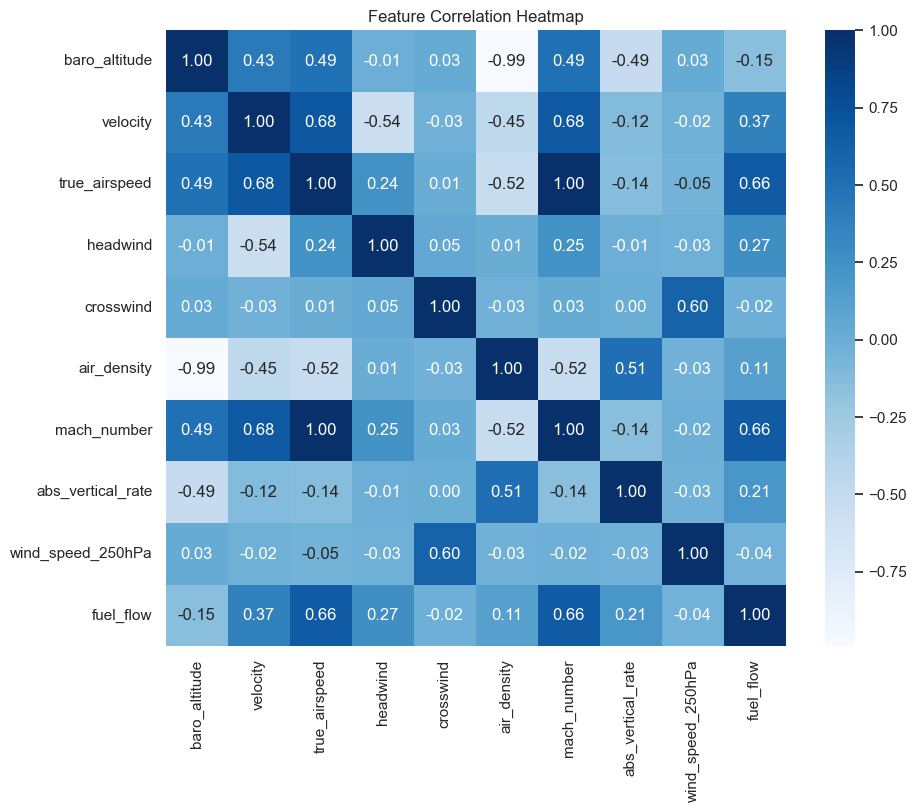

In [6]:
feature_cols = ['baro_altitude', 'velocity', 'true_airspeed', 'headwind', 'crosswind',
                'air_density', 'mach_number', 'abs_vertical_rate',
                'wind_speed_250hPa', 'fuel_flow']

corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


---
## 4. ML Model Training

In [7]:
FEATURES = [
    'baro_altitude', 'velocity', 'true_airspeed', 'headwind', 'crosswind',
    'mach_number', 'abs_vertical_rate',
    'wind_speed_250hPa', 'temperature_250hPa'
]
TARGET = 'fuel_flow'

X = df[FEATURES].copy()
y = df[TARGET].copy()
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')

Training set: 800 samples


In [8]:
def evaluate_model_cv(model, X, y, model_name, cv=5):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    print(f'{model_name} CV R2: {r2_scores.mean():.4f}')
    return pipe.fit(X, y)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pipe = evaluate_model_cv(rf_model, X_train, y_train, 'Random Forest')

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_pipe = evaluate_model_cv(xgb_model, X_train, y_train, 'XGBoost')

best_pipeline = xgb_pipe
best_name = 'XGBoost'

Random Forest CV R2: 0.7266
XGBoost CV R2: 0.6697


---
## 5. Model Evaluation & Explainability

Test R2: 0.5969
Test MAE: 85.36


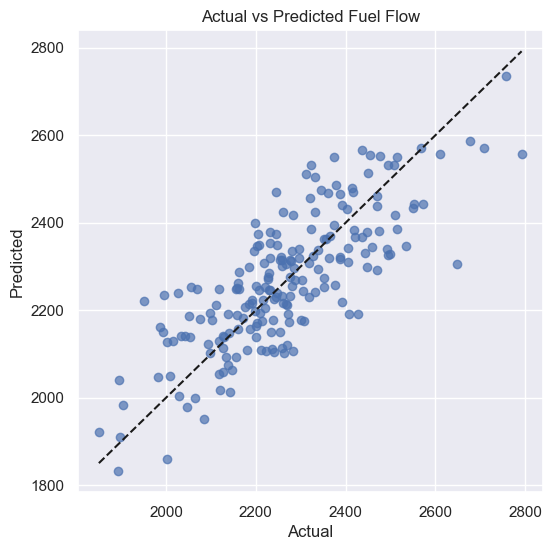

In [9]:
y_pred = best_pipeline.predict(X_test)
print(f'Test R2: {r2_score(y_test, y_pred):.4f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred):.2f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.title('Actual vs Predicted Fuel Flow')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

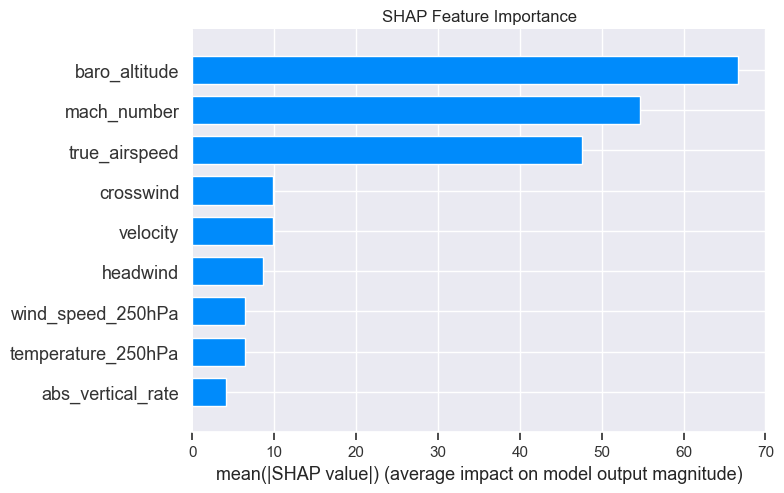

In [10]:
trained_model = best_pipeline.named_steps['model']
scaler = best_pipeline.named_steps['scaler']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

explainer = shap.TreeExplainer(trained_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

---
## 6. Save Artifacts

In [11]:
joblib.dump(best_pipeline, 'model.joblib')
with open('features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('Artifacts saved. Finished.')

Artifacts saved. Finished.
